In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize

In [4]:
# read data
dr = pd.read_excel("euro_discount.xlsx")

## The present value of the floating leg

In [14]:
PV_float = (1-dr['P(t,Ti)'].iloc[-1])
print(PV_float)

0.006547999999999998


## The present value of the annuity 

In [26]:
annuity = 1/12*float(dr['P(t,Ti)'].sum())
print(annuity)

0.9973117499999998


## The fixed Swap rate

In [30]:
f_t = PV_float/annuity
print(f_t)

0.006565650108905264


# Calibration of the Vasicek Model
## using Affine Formula for the zero-coupon bond and the discount curve

In [48]:


def mse(params, P_mkt):
    mu, lamb, sigma, r = params
    
    t = np.arange(1, len(P_mkt)+1) / 12
    B_t = (1 - np.exp(-lamb * t)) / lamb
    A_t = (B_t - t) * (mu - sigma**2 / (2 * lamb**2)) - (sigma**2 * B_t**2) / (4 * lamb)
    
    P_model = np.exp(A_t - B_t * r)
    
    return np.sum((P_mkt - P_model)**2)

# Initial guesses (VERY important)
init_params = [0.05, 0.2, 0.01, 0.01]  
# mu, lambda, sigma, r

# Bounds (to avoid nonsense values)
bounds = [
    (-1, 1),     # mu
    (1e-4, 5),   # lambda > 0
    (1e-4, 1),   # sigma > 0
    (-0.1, 0.2)  # r
]


P_mkt = dr['P(t,Ti)']

result = minimize(
    mse,
    init_params,
    args=(P_mkt,),
    method='Nelder-Mead'
# ,
    # bounds=bounds
)

mu_opt, lamb_opt, sigma_opt, r_opt = result.x

print("Optimized parameters:")
print("mu =", mu_opt)
print("lambda =", lamb_opt)
print("sigma =", sigma_opt)
print("r =", r_opt)

Optimized parameters:
mu = 0.055619017527257106
lambda = 0.21715767835582664
sigma = 0.013489795143979617
r = 0.0011051693594682553


In [187]:
r = 0.088/100
mu = 0.02768
sigma = 0.0102
lamb = 0.49


In [341]:
def simulate_vasicek(mu,sigma,lamb,r,N=12,M=100000):
    dt = 1/N
    t_grid = np.linspace(0,1,N+1)
    Z = np.random.randn(N,M)
    
    R = np.zeros((N+1,M))
    R[0] = r

    for i in range(1,N+1):
        drift = mu + np.exp(-lamb*dt) * (R[i-1]-mu)
        vol = np.sqrt(sigma**2 /(2*lamb)*(1-np.exp(-2* lamb*dt)))
        R[i] = drift + vol * Z[i-1]
    return R

def simulate_money_market_account(R):
    N,M = R.shape
    MMA = np.ones((N,M))
    dt = 1/(N-1)
    for i in range(1,N):
        MMA[i] = MMA[i-1]*np.exp(dt/2*(R[i-1]+R[i]))

    return MMA



def compute_exposure(s, mu, sigma, lamb, R, f_t):
    N, M = R.shape
    dt = 1/(N-1)
    
    # time grid from s to maturity
    t_grid = np.arange(s, 1+dt, dt)
    tau = t_grid - s
    
    # correct index
    r_idx = int(s*(N-1))
    r_s = R[r_idx]   # shape (M,)
    
    # Vasicek bond coefficients
    B = (1 - np.exp(-lamb * tau)) / lamb
    A = (B - tau)*(mu - sigma**2/(2*lamb**2)) - (sigma**2 * B**2)/(4*lamb)
    
    # bond prices (vectorized)
    P_k = np.exp(A[:, None] - B[:, None] * r_s[None, :])
    
    # annuity (exclude first point tau=0)
    annuity = dt * np.sum(P_k[1:], axis=0)
    
    # swap value
    FV = (1 - P_k[-1]) - f_t * annuity
    
    # exposures
    E_A = np.maximum(FV, 0)
    E_B = np.maximum(-FV, 0)
        
    return FV, E_A, E_B

def compute_CVAs(RA,RB,QA,QB,mu,sigma,lamb,R,f_T,MMA):
    N,M  = R.shape
    dt = 1/N
    t_grid = np.arange(0,1+dt,dt)
    hazard_A = -np.log(QA)
    hazard_B = -np.log(QB)

    # Compute the survival_default_grid
    Q_A = np.ones((N,M))
    Q_B = np.ones((N,M))
    D_A = np.ones((N,M))
    D_B = np.ones((N,M))
    

    CVA_A = np.zeros((N,M))
    CVA_B = np.zeros((N,M))

    QA_prev = QA
    QB_prev = QB
    
    for i in range(N):
        s = i*dt
        Q_A[i] = np.exp(-hazard_A*s)
        Q_B[i] = np.exp(-hazard_B*s)
        D_A[i] = QA_prev - Q_A[i]
        D_B[i] = QB_prev - Q_B[i]

        
        FV,E_A,E_B = compute_exposure(s,mu,sigma,lamb,R,f_t)
        CVA_A[i] = (1-RB) * Q_A[i]*D_B[i] * E_A[i]/MMA[i]
        CVA_B[i] = (1-RA) * Q_B[i]* D_A[i] * E_B[i]/MMA[i]

        QA_Prev = Q_A[i]
        QB_prev = Q_B[i]

    CVA_A_sim = CVA_A.sum(axis=0)
    CVA_B_sim = CVA_B.sum(axis=0)

    CVA = np.average(CVA_A_sim)
    DVA = np.average(CVA_B_sim)

    print(CVA,DVA)
        

    


    

    
    

    

In [342]:
R = simulate_vasicek(mu,sigma,lamb,r)
MMA = simulate_money_market_account(R)


In [343]:
compute_CVAs(0.4,0.4,0.9989,0.9983,mu,sigma,lamb,R,f_t,MMA)

1.5679572143016918e-06 -8.342564654956727e-07


# Pricing of the CVA

In [271]:
X = np.arange(0.25,1+0.01,1/12)
Y = np.arange(0,1+0.01,1/12)

In [230]:
12*0.25

3.0

In [241]:
R = simulate_vasicek(mu,sigma,lamb,r)
MMA = simulate_money_market_account(R)

FV,_,_ = compute_exposure(0.25,mu,sigma,lamb,R,f_t)

In [242]:
np.mean(FV)


np.float64(6.191086564204009e-05)

(array([9.0000e+00, 2.8000e+02, 2.7260e+03, 1.2798e+04, 2.8895e+04,
        3.2216e+04, 1.7622e+04, 4.8070e+03, 6.0500e+02, 4.2000e+01]),
 array([-0.01379034, -0.01110306, -0.00841578, -0.0057285 , -0.00304121,
        -0.00035393,  0.00233335,  0.00502063,  0.00770791,  0.01039519,
         0.01308247]),
 <BarContainer object of 10 artists>)

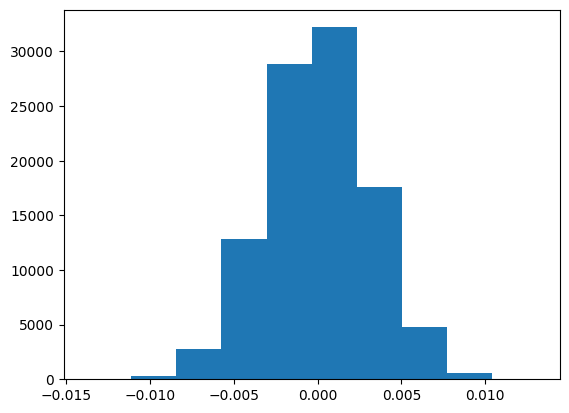

In [243]:
plt.hist(FV)

In [288]:
import numpy as np

# -----------------------------
# 1. Simulate Vasicek short rates
# -----------------------------
def simulate_vasicek(mu, sigma, lamb, r0, N=12, M=100000):
    dt = 1/N
    Z = np.random.randn(N, M)
    
    R = np.zeros((N+1, M))
    R[0] = r0

    for i in range(1, N+1):
        drift = mu + np.exp(-lamb*dt) * (R[i-1] - mu)
        vol = np.sqrt(sigma**2/(2*lamb)*(1 - np.exp(-2*lamb*dt)))
        R[i] = drift + vol * Z[i-1]

    return R


# -----------------------------
# 2. Money Market Account
# -----------------------------
def simulate_money_market_account(R):
    N, M = R.shape
    MMA = np.ones((N, M))
    dt = 1/(N-1)

    for i in range(1, N):
        MMA[i] = MMA[i-1] * np.exp(dt/2 * (R[i-1] + R[i]))

    return MMA


# -----------------------------
# 3. Exposure calculation
# -----------------------------
def compute_exposure(s, mu, sigma, lamb, R, f_t):
    N, M = R.shape
    dt = 1/(N-1)
    
    t_grid = np.linspace(s, 1, int((1-s)/dt) + 1)
    tau = t_grid - s
    
    r_idx = int(round(s*(N-1)))
    r_s = R[r_idx]
    
    B = (1 - np.exp(-lamb * tau)) / lamb
    A = (B - tau)*(mu - sigma**2/(2*lamb**2)) - (sigma**2 * B**2)/(4*lamb)
    
    P_k = np.exp(A[:, None] - B[:, None] * r_s[None, :])
    
    annuity = dt * np.sum(P_k[1:], axis=0)
    
    FV = (1 - P_k[-1]) - f_t * annuity
    
    E_A = np.maximum(FV, 0)
    E_B = np.maximum(-FV, 0)
        
    return FV, E_A, E_B


# -----------------------------
# 4. CVA / DVA computation
# -----------------------------
def compute_CVAs(RA, RB, QA, QB, mu, sigma, lamb, R, f_t, MMA):
    N, M = R.shape
    dt = 1/(N-1)

    # constant hazard rates
    lambda_A = -np.log(QA)
    lambda_B = -np.log(QB)

    CVA_path = np.zeros(M)
    DVA_path = np.zeros(M)

    Q_A_prev = 1.0
    Q_B_prev = 1.0

    for i in range(1, N):
        t = i * dt
        
        # survival probabilities
        Q_A = np.exp(-lambda_A * t)
        Q_B = np.exp(-lambda_B * t)
        
        # incremental default probabilities
        dQ_A = Q_A_prev - Q_A
        dQ_B = Q_B_prev - Q_B
        
        # exposure
        _, E_A, E_B = compute_exposure(t, mu, sigma, lamb, R, f_t)
        
        # discount factor
        discount = 1 / MMA[i]
        
        # CVA and DVA
        CVA_path += (1 - RB) * Q_A * dQ_B * E_A * discount
        DVA_path += (1 - RA) * Q_B * dQ_A * E_B * discount
        
        # update survival
        Q_A_prev = Q_A
        Q_B_prev = Q_B

    CVA = np.mean(CVA_path)
    DVA = np.mean(DVA_path)

    return CVA, DVA


# -----------------------------
# 5. Run everything
# -----------------------------
# if __name__ == "__main__":
    
    # # Model parameters
    # mu = 0.05
    # sigma = 0.01
    # lamb = 0.3
    # r0 = 0.05
    
# Credit parameters
RA = 0.4   # recovery A
RB = 0.4   # recovery B
QA = 0.9989   # 1-month survival A
QB = 0.9983   # 1-month survival B

    # # Swap fixed rate
    # f_t = 0.05
    
    # Simulation
N = 12
M = 100000

R = simulate_vasicek(mu, sigma, lamb, r, N, M)
MMA = simulate_money_market_account(R)

CVA, DVA = compute_CVAs(RA, RB, QA, QB, mu, sigma, lamb, R, f_t, MMA)

print("CVA:", CVA)
print("DVA:", DVA)

CVA: 1.334394000937434e-06
DVA: 3.27318063031803e-07


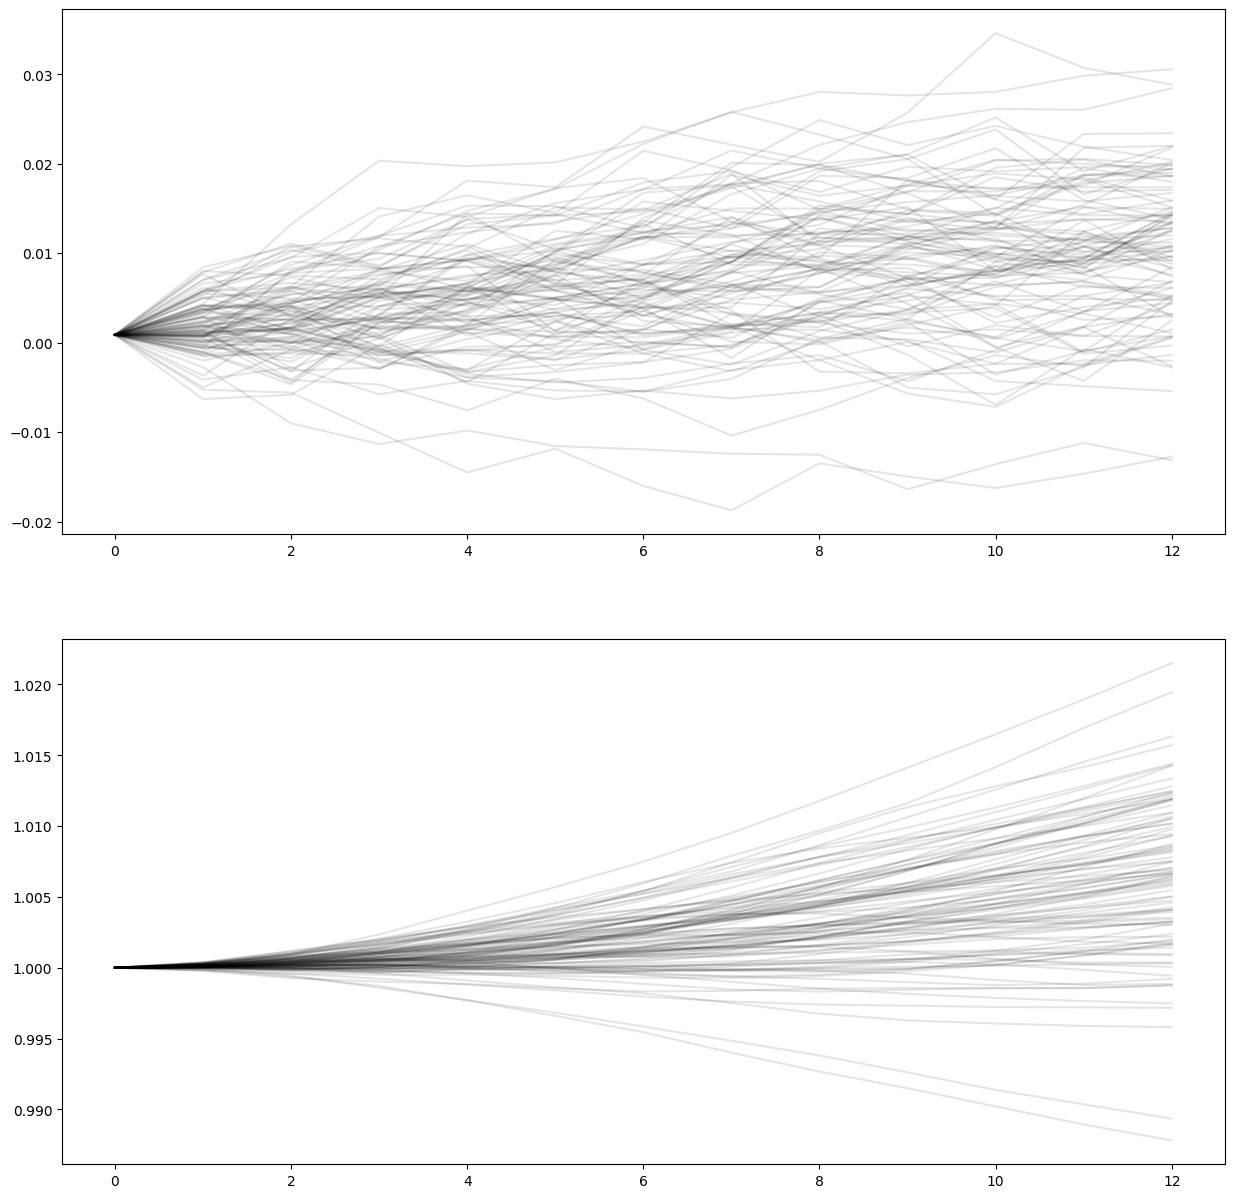

In [331]:
fig,ax=plt.subplots(2,1,figsize=(15,15))
for i in range(100):
    idx = round(np.random.rand()*M)
    ax[0].plot(R.T[idx],c='k',alpha=0.1)
    ax[1].plot(MMA.T[idx],c='k',alpha=0.1)